In [2]:
import pandas as pd 
import numpy as np
import matplotlib.pyplot as plt

In [13]:
df = pd.read_csv("../data/churn.csv")
df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [14]:
df.isna().sum().sum()

np.int64(0)


Not really much to clean. We can go ahead to EDA

In [15]:
print(df.shape)
df.info()

(7043, 21)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-null

We see TotalCharges are object type, when they should be a numeric type. We can fix that

In [16]:
df["TotalCharges"] = pd.to_numeric(df["TotalCharges"], errors="coerce")
df = df.dropna()

We check the distriution of our target 

In [18]:
df["Churn"].value_counts(normalize=True)

Churn
No     0.734215
Yes    0.265785
Name: proportion, dtype: float64

We see the disribution is indeed skewed. This will affect our model if we dont fix it. We check the distribution of the data

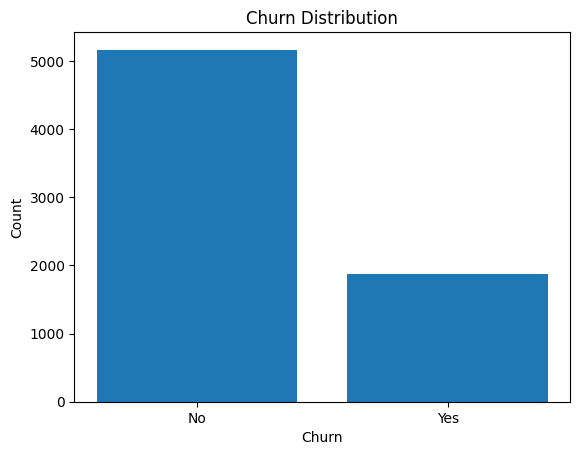

In [20]:
counts = df["Churn"].value_counts()
plt.bar(counts.index, counts.values)
plt.xlabel("Churn")
plt.ylabel("Count")
plt.title("Churn Distribution")
plt.show()

There is a chance Churn may be related to Tenure. We check our assumption

C:\Users\Anupam Dasgupta\AppData\Local\Temp\ipykernel_134980\329492436.py:5: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot([no_churn, yes_churn], labels=["No", "Yes"])


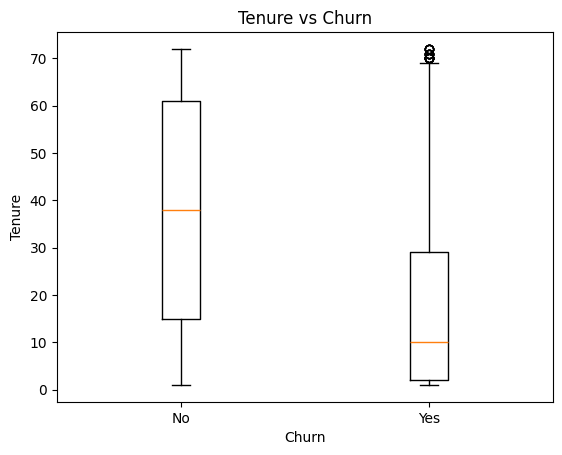

In [21]:
# split data by class
no_churn = df[df["Churn"] == "No"]["tenure"]
yes_churn = df[df["Churn"] == "Yes"]["tenure"]

plt.boxplot([no_churn, yes_churn], labels=["No", "Yes"])
plt.xlabel("Churn")
plt.ylabel("Tenure")
plt.title("Tenure vs Churn")
plt.show()

The above graph seems to agree with our assumption. Higher tenures tend to be associated with Not churning.
Lets check for monthly charges as well

C:\Users\Anupam Dasgupta\AppData\Local\Temp\ipykernel_134980\2044562104.py:4: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot([no_churn, yes_churn], labels=["No", "Yes"])


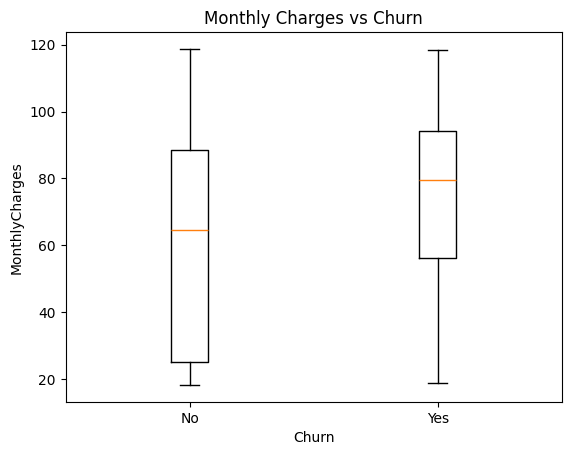

In [22]:
no_churn = df[df["Churn"] == "No"]["MonthlyCharges"]
yes_churn = df[df["Churn"] == "Yes"]["MonthlyCharges"]

plt.boxplot([no_churn, yes_churn], labels=["No", "Yes"])
plt.xlabel("Churn")
plt.ylabel("MonthlyCharges")
plt.title("Monthly Charges vs Churn")
plt.show()

We see that lower monthly charges also tend to be associated wiht not churning

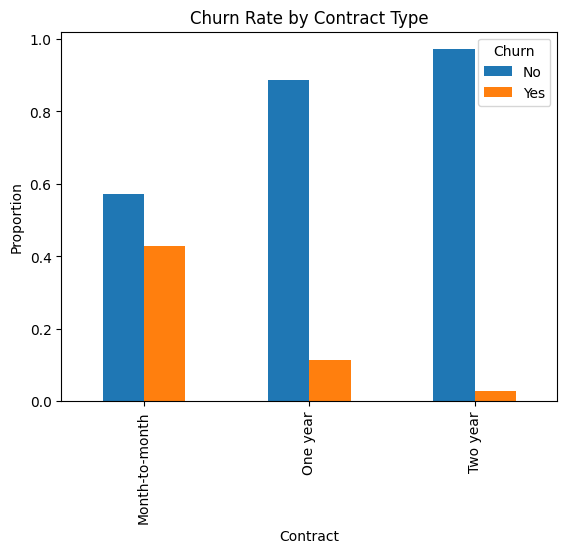

In [35]:
churn_rate_contract = pd.crosstab(df["Contract"], df["Churn"], normalize="index")

churn_rate_contract.plot(kind="bar")
plt.title("Churn Rate by Contract Type")
plt.ylabel("Proportion")
plt.show()


Customers on month-to-month contracts exhibit significantly higher churn compared to those on longer-term contracts, indicating contract length is a strong retention factor.

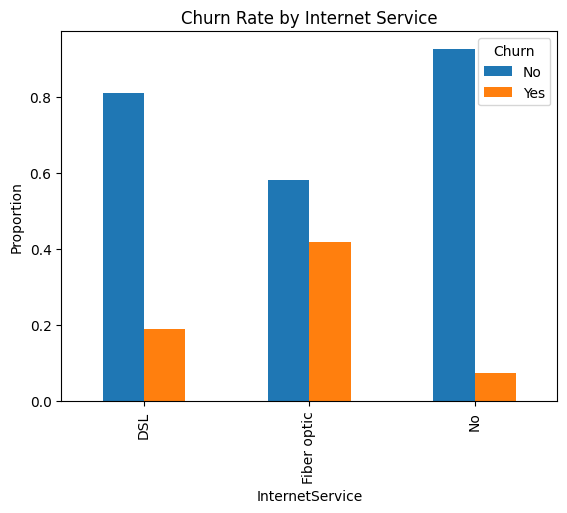

In [36]:
churn_rate_internet = pd.crosstab(df["InternetService"], df["Churn"], normalize="index")

churn_rate_internet.plot(kind="bar")
plt.title("Churn Rate by Internet Service")
plt.ylabel("Proportion")
plt.show()

Customers using fiber optic services show higher churn rates, possibly due to higher costs or service expectations.

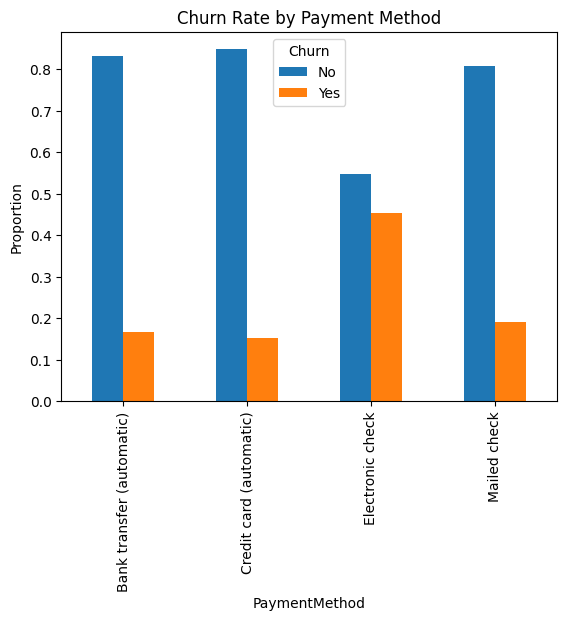

In [37]:
churn_rate_payment = pd.crosstab(df["PaymentMethod"], df["Churn"], normalize="index")

churn_rate_payment.plot(kind="bar")
plt.title("Churn Rate by Payment Method")
plt.ylabel("Proportion")
plt.show()

Customers using electronic check payment methods have higher churn rates, suggesting that automated payment options may improve retention.

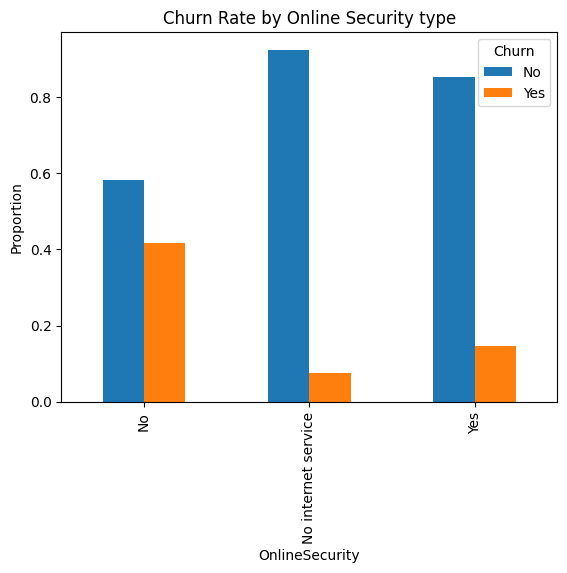

In [38]:
churn_rate_security = pd.crosstab(df["OnlineSecurity"], df["Churn"], normalize="index")

churn_rate_security.plot(kind="bar")
plt.title("Churn Rate by Online Security type")
plt.ylabel("Proportion")
plt.show()

Customers without online security services are significantly more likely to churn, indicating value-added services improve retention.

To better understand how customer tenure impacts churn behavior, customers are grouped into tenure buckets. This allows analysis of churn patterns across different stages of the customer lifecycle.

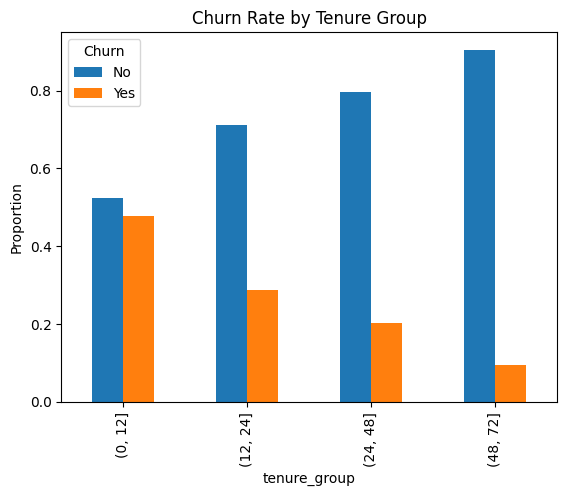

In [39]:
df["tenure_group"] = pd.cut(df["tenure"], bins=[0,12,24,48,72])
churn_rate = pd.crosstab(df["tenure_group"], df["Churn"], normalize="index")

churn_rate.plot(kind="bar")
plt.title("Churn Rate by Tenure Group")
plt.ylabel("Proportion")
plt.show()

Customers in lower tenure groups exhibit significantly higher churn rates, while long-tenure customers are more stable. This suggests that early-stage customer retention is critical for reducing overall churn.

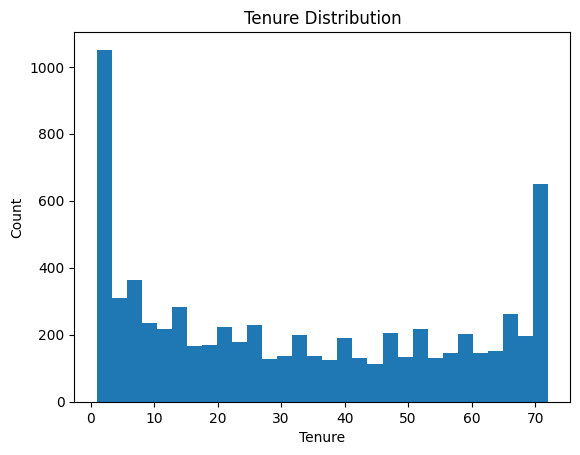

In [29]:
plt.hist(df["tenure"], bins=30)
plt.title("Tenure Distribution")
plt.xlabel("Tenure")
plt.ylabel("Count")
plt.show()

The bimodal tenure distribution suggests the presence of both newly acquired and loyal long-term customers, with churn likely concentrated among early-stage customers.

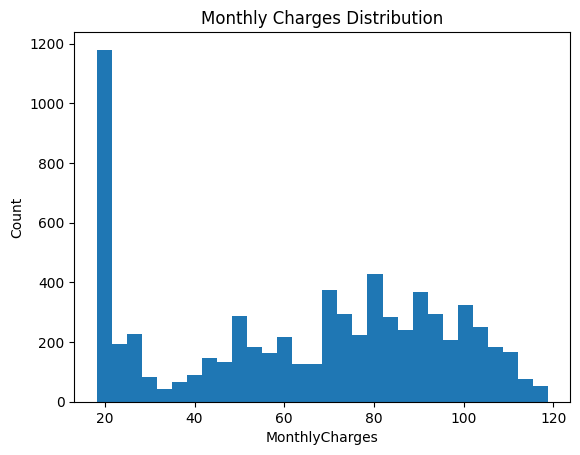

In [30]:
plt.hist(df["MonthlyCharges"], bins=30)
plt.title("Monthly Charges Distribution")
plt.xlabel("MonthlyCharges")
plt.ylabel("Count")
plt.show()

The distribution of monthly charges is right-skewed, indicating most customers are concentrated in lower pricing tiers, while a smaller segment incurs significantly higher charges.

This suggests pricing is tiered, with a majority of customers opting for basic plans and fewer customers in premium tiers.

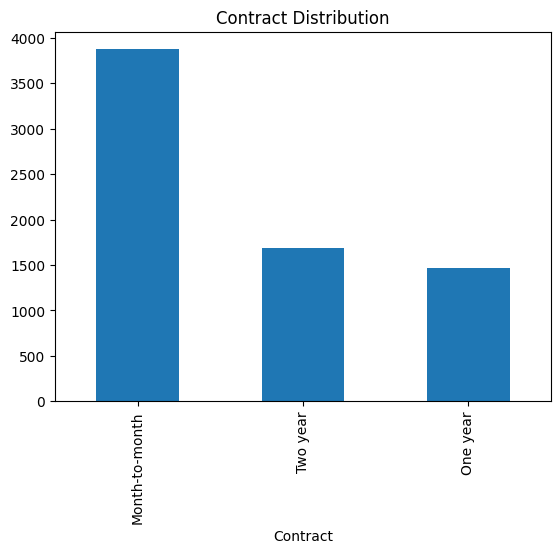

In [34]:
df["Contract"].value_counts().plot(kind="bar")
plt.title("Contract Distribution")
plt.show()

Majority of customers are on month-to-month contracts, which aligns with higher observed churn rates.

The exploratory analysis reveals several clear patterns associated with customer churn. Contract type emerges as a strong determinant, with month-to-month customers exhibiting significantly higher churn compared to those on longer-term contracts. Customer tenure also plays a critical role, with early-stage customers showing a higher propensity to churn, while long-tenure customers demonstrate greater stability. Additionally, higher monthly charges and the absence of value-added services such as online security are associated with increased churn rates.

The distributional analysis further supports these findings. Monthly charges exhibit a right-skewed distribution, indicating a concentration of customers in lower pricing tiers, while tenure shows a bimodal pattern, reflecting a mix of newly acquired and long-term customers. These structural patterns suggest that churn is not uniformly distributed across the customer base but is concentrated within specific segments, particularly among newer customers and those with less commitment or engagement.

Based on these insights, the next step is to translate these observed patterns into a robust predictive modeling pipeline. This will involve preprocessing the data through appropriate encoding of categorical variables and scaling of numerical features, along with handling class imbalance to ensure reliable performance on the minority churn class. Multiple classification models, including Logistic Regression and XGBoost, will be evaluated using stratified cross-validation, with a focus on metrics such as ROC-AUC and F1-score rather than accuracy.

Finally, model outputs will be analyzed to identify key drivers of churn and validate whether the patterns observed during EDA are captured by the predictive models. This will ensure that the final model is not only accurate but also aligned with the underlying data structure and business intuition derived from the exploratory analysis.